Name:Madhavi katekhaye
roll no:22
batch:b2
section:b
ML LAB 7


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    
    classification_report
)


In [ ]:
df = pd.read_excel("Raisin_Dataset.xlsx")

In [ ]:
df.head()


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [ ]:
df.tail()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
895,83248,430.077308,247.838695,0.817263,85839,0.668793,1129.072,Besni
896,87350,440.735698,259.293149,0.808629,90899,0.636476,1214.252,Besni
897,99657,431.706981,298.837323,0.721684,106264,0.741099,1292.828,Besni
898,93523,476.344094,254.176054,0.845739,97653,0.658798,1258.548,Besni
899,85609,512.081774,215.271976,0.907345,89197,0.632020,1272.862,Besni


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 900
Columns: 8


In [ ]:
print(df.columns)

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'Extent', 'Perimeter', 'Class'],
      dtype='str')


In [ ]:
df.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


In [ ]:
df.isnull().sum()

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64

In [ ]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [ ]:
df = df.drop_duplicates()

In [ ]:
for col in df.columns:
    print(col, ":", df[col].nunique())

Area : 900
MajorAxisLength : 900
MinorAxisLength : 900
Eccentricity : 900
ConvexArea : 896
Extent : 900
Perimeter : 900
Class : 2


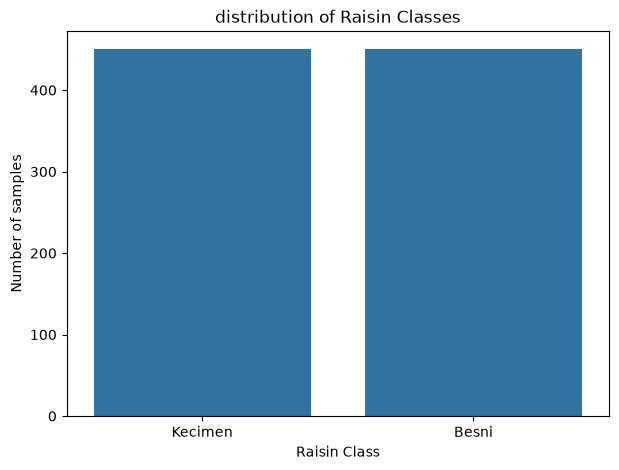

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="Class")
plt.title("distribution of Raisin Classes")
plt.xlabel("Raisin Class")
plt.ylabel("Number of samples")
plt.show()

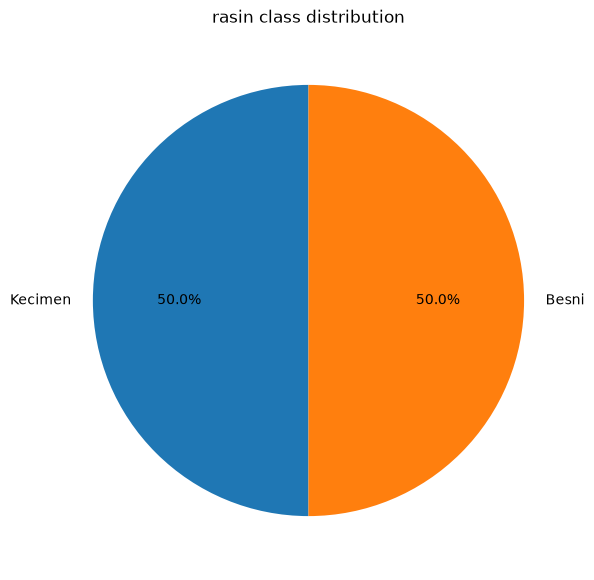

In [ ]:
class_counts=df["Class"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(class_counts,labels=class_counts.index,autopct="%1.1f%%",startangle=90)
plt.title("rasin class distribution")
plt.show()

In [ ]:
numerical_features = df.select_dtypes(include=np.number).columns
print(numerical_features)

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'Extent', 'Perimeter'],
      dtype='str')


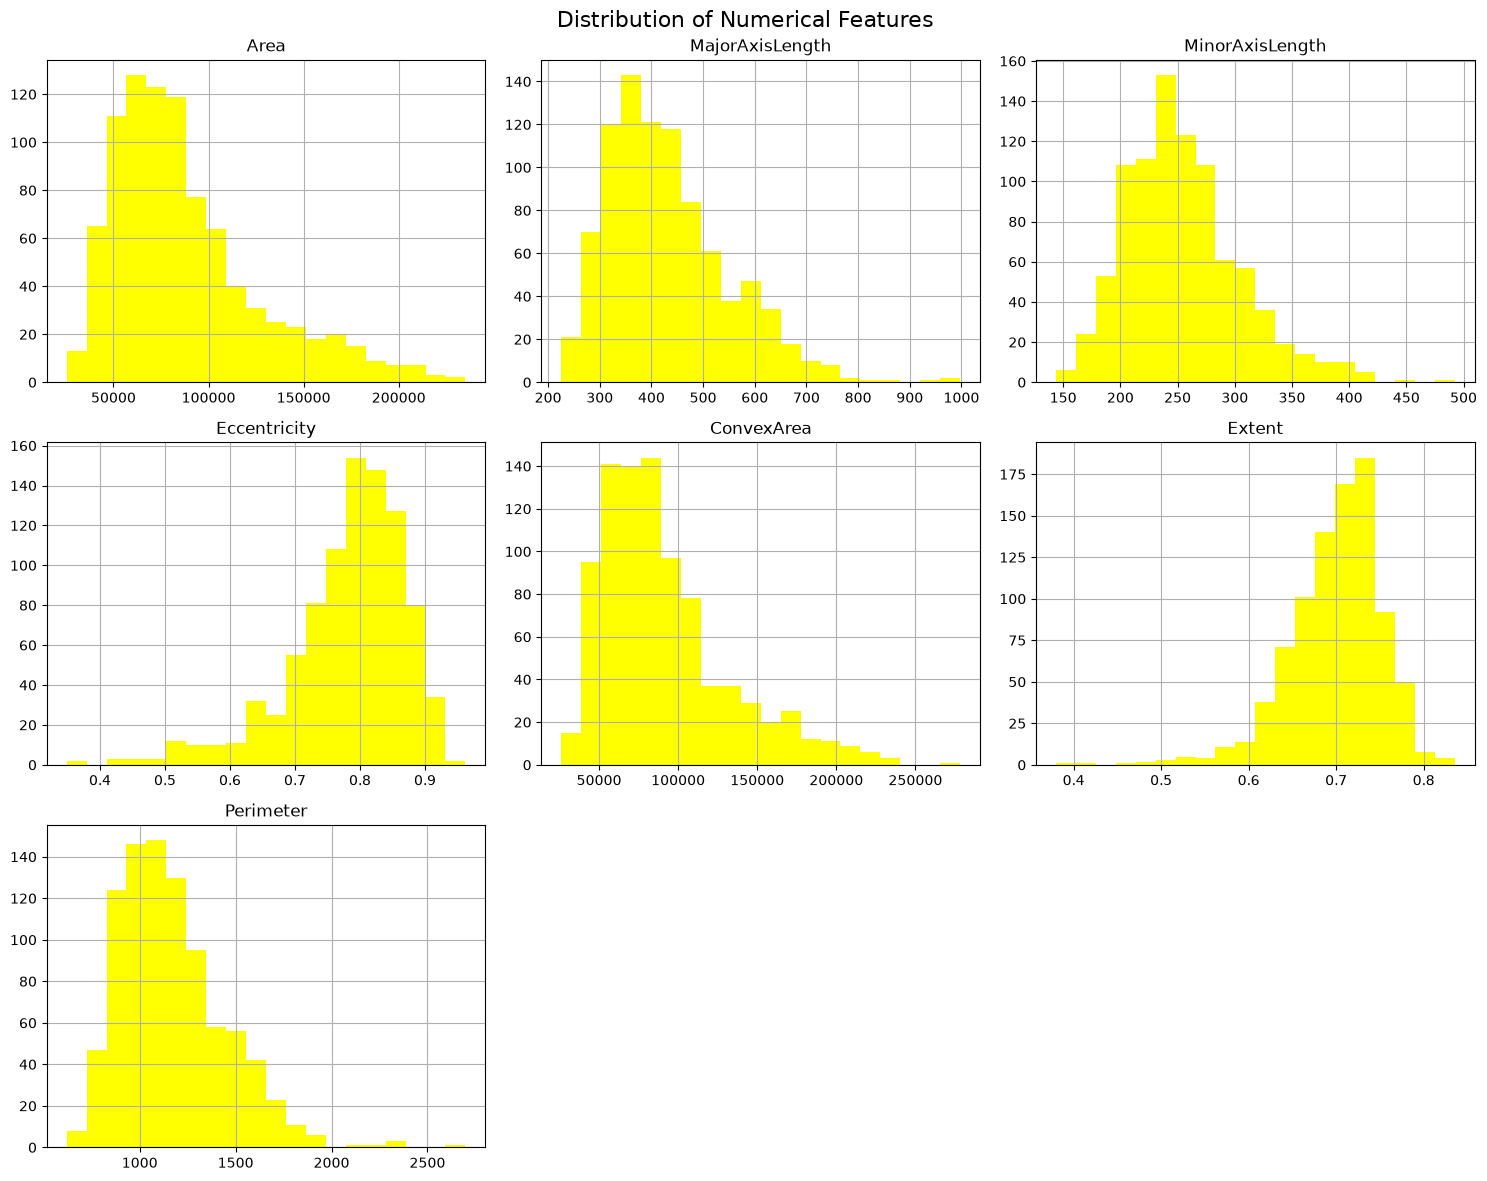

In [ ]:
df[numerical_features].hist(figsize=(15,12), bins=20, color='yellow')

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()
plt.show()

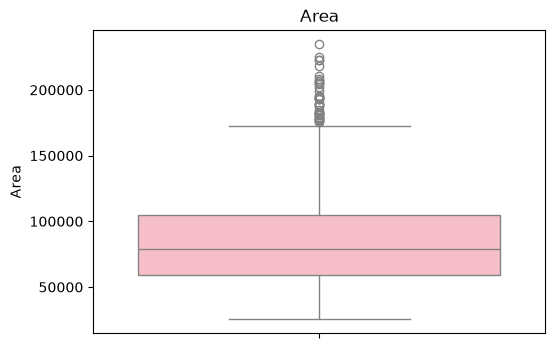

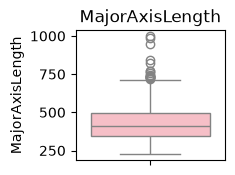

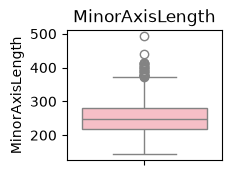

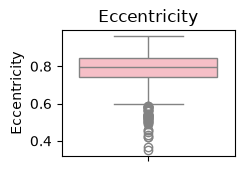

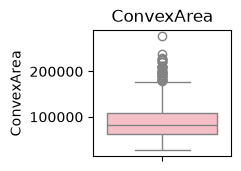

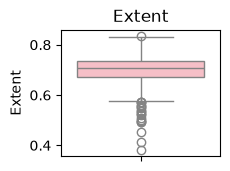

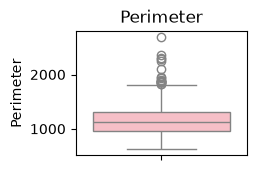

In [ ]:
plt.figure(figsize=(15,10))
for i ,column in enumerate(numerical_features,1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[column],color='lightpink')
    plt.title(column)
    plt.tight_layout()
    plt.show()

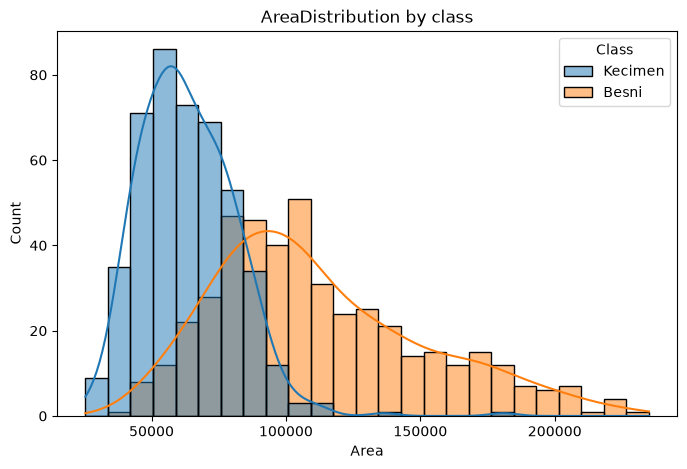

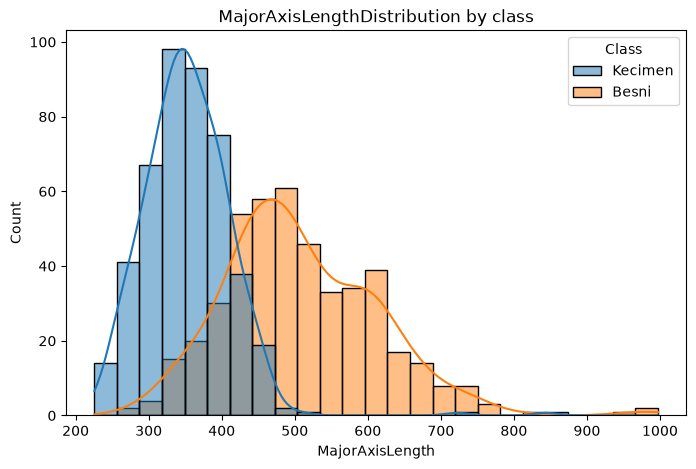

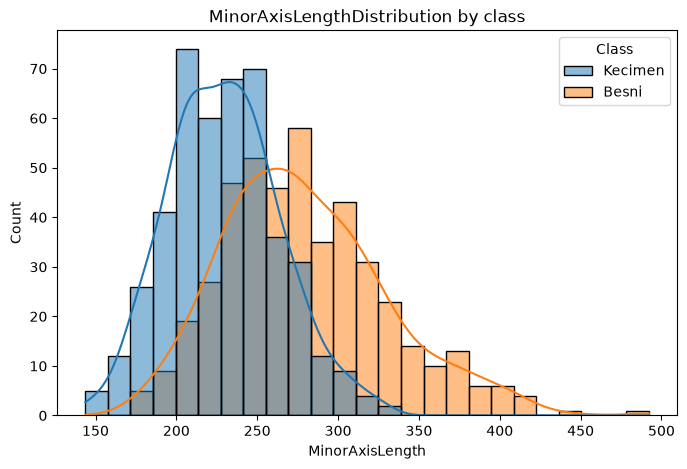

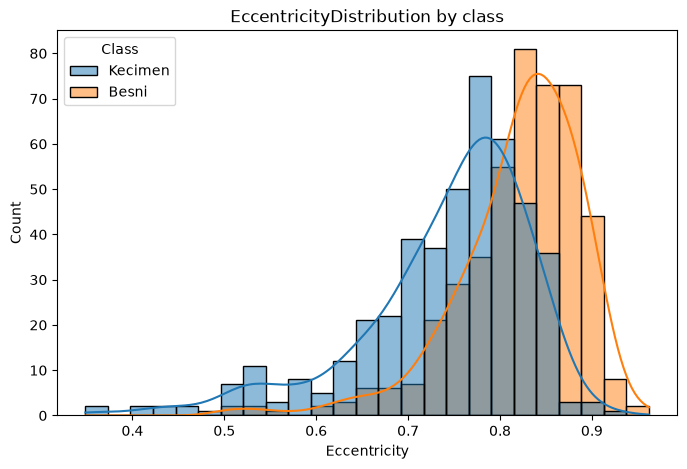

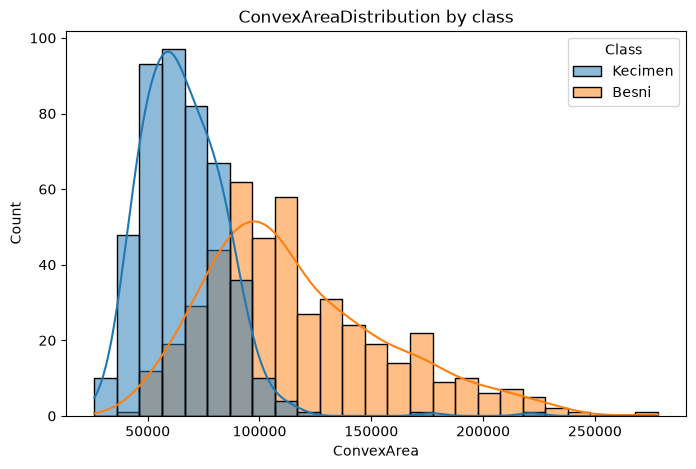

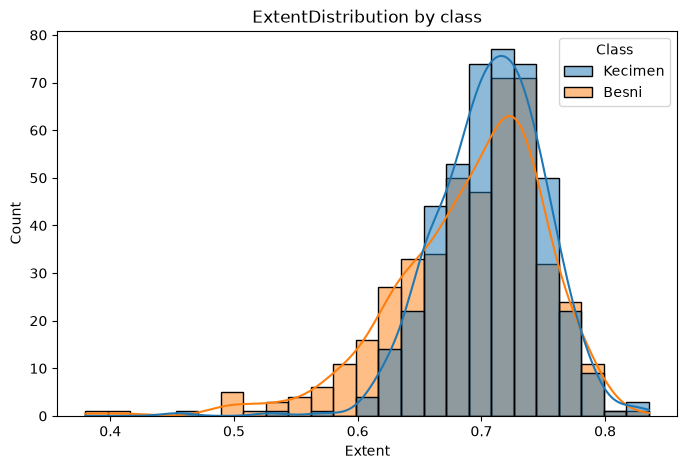

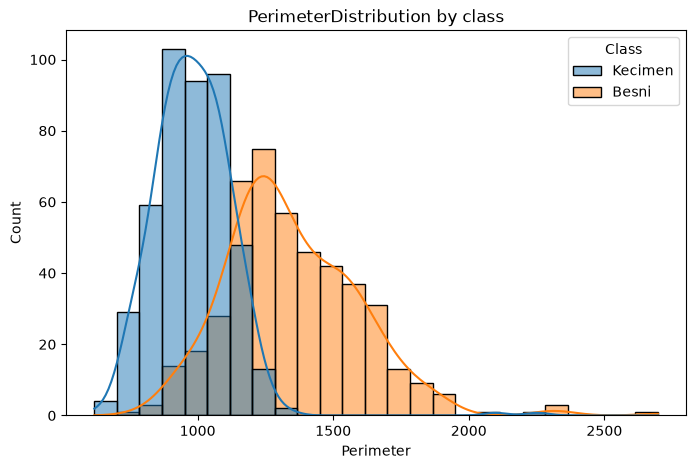

In [ ]:
for column in numerical_features:
    plt.figure(figsize=(8,5))
    sns.histplot(data=df,x=column,hue="Class",kde=True,bins=25)
    plt.title(f"{column}Distribution by class")
    plt.show()

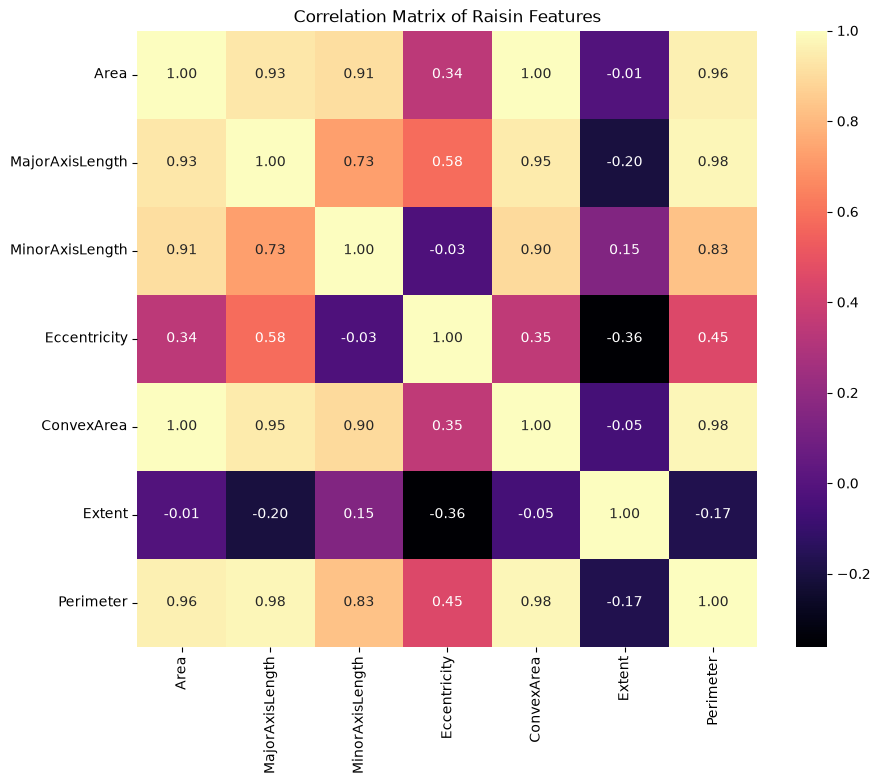

In [ ]:
correlation_matrix=df[numerical_features].corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="magma")
plt.title("Correlation Matrix of Raisin Features")
plt.show()

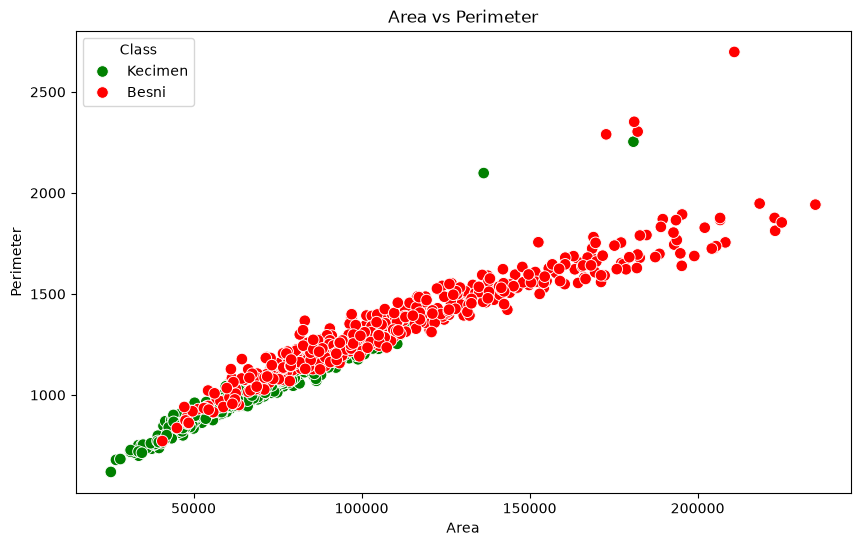

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Area",
    y="Perimeter",
    hue="Class",
    palette={"Kecimen": "green", "Besni": "red"},
    s=70
)

plt.title("Area vs Perimeter")
plt.xlabel("Area")
plt.ylabel("Perimeter")
plt.show()

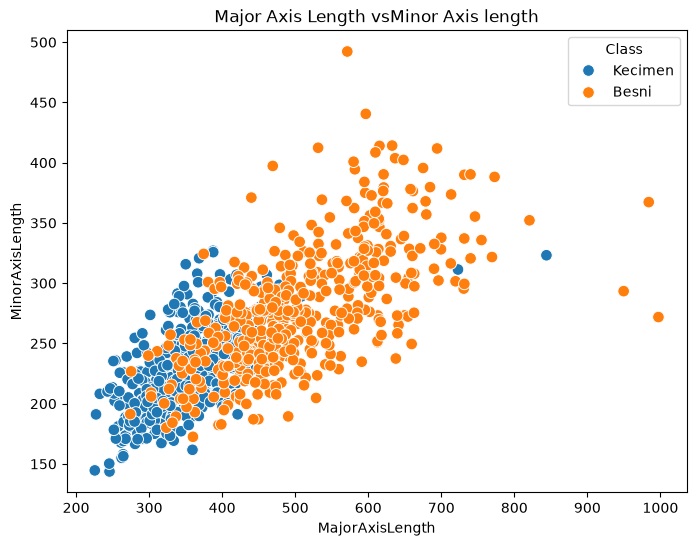

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x="MajorAxisLength",y="MinorAxisLength",hue="Class",s=70)
plt.title("Major Axis Length vsMinor Axis length")
plt.show()

In [ ]:
#DATA PRE-PROCESSING
label_encoder=LabelEncoder()
df["Class_encoded"]=label_encoder.fit_transform(df["Class"])
print(df[["Class","Class_encoded"]].head(5))


     Class  Class_encoded
0  Kecimen              1
1  Kecimen              1
2  Kecimen              1
3  Kecimen              1
4  Kecimen              1


In [ ]:
print("Class mapping :")
for index,class_name in enumerate (label_encoder.classes_):
    print(index,"=",class_name)

Class mapping :
0 = Besni
1 = Kecimen


In [ ]:
X=df[numerical_features]
y=df["Class_encoded"]
print("X shape :",X.shape)
print("y shape:",y.shape)

X shape : (900, 7)
y shape: (900,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (720, 7)
X_test Shape: (180, 7)
y_train Shape: (720,)
y_test Shape: (180,)


In [ ]:
GaussianNB()

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [ ]:
gnb=GaussianNB()
gnb.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[360.,360.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.691
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Area','MajorAxisLength','MinorAxisLength',...,'ConvexArea','Extent', 'Perimeter']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 7)","[[113429.81, 513.27, 280.59,...,118068.15, 0.69, 1357.66], [ 63707.9 , 353.69, 229.97,..., 65944.35, 0.71, 985.65]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 7)","[[1.56e+09,1.17e+04,2.52e+03,...,1.71e+09,1.70e+00,6.32e+04], [2.90e+08,3.10e+03,1.16e+03,...,3.18e+08,1.69e+00,1.98e+04]]"


In [ ]:
y_pred=gnb.predict(X_test)
print("Predicted labels")
print(y_pred)

Predicted labels
[1 0 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1
 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 0 1 1 0 0 1 0 1 1 1 1 0 0 1
 1 1 0 1 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1 0 1 0 1 0 1 1 0
 1 1 0 1 1 1 0 0 1 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1
 1 1 1 0 0 1 1 1 0 1 1 0 1 1 0 0 0 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1]


In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison)

     Actual  Predicted
502       0          1
637       0          0
701       0          0
237       1          1
707       0          0
..      ...        ...
499       0          0
538       0          0
780       0          1
702       0          0
9         1          1

[180 rows x 2 columns]


In [ ]:
comparison["Actual_Class"]=label_encoder.inverse_transform(comparison["Actual"])
comparison["Predicted_Class"] = label_encoder.inverse_transform(comparison["Predicted"])
comparison.head(5)

,Actual,Predicted,Actual_Class,Predicted_Class
502,0,1,Besni,Kecimen
637,0,0,Besni,Besni
701,0,0,Besni,Besni
237,1,1,Kecimen,Kecimen
707,0,0,Besni,Besni


In [ ]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy :",accuracy)
print("Accuracy (%) :",accuracy*100)


Accuracy : 0.8166666666666667
Accuracy (%) : 81.66666666666667


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Accuracy (%) :", accuracy * 100)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.8166666666666667
Accuracy (%) : 81.66666666666667
Precision : 0.7522123893805309
Recall : 0.9444444444444444
F1 Score : 0.8374384236453202


In [ ]:
cm=confusion_matrix(y_test,y_pred)
print("confusion matrix")
print(cm)

confusion matrix
[[62 28]
 [ 5 85]]


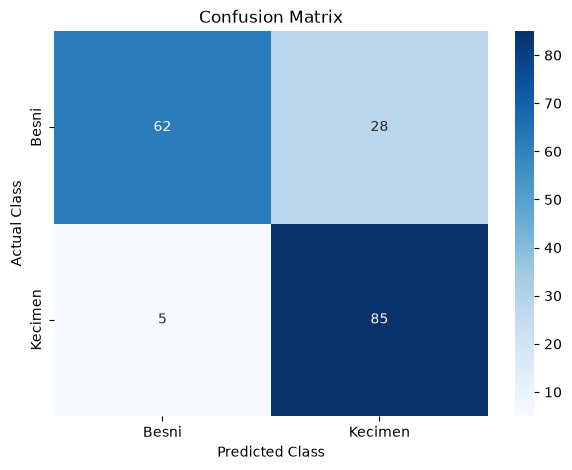

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

y_train_pred = gnb.predict(X_train)
y_test_pred = gnb.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)


print("Testing Accuracy:", test_accuracy)


Training Accuracy: 0.8263888888888888
Testing Accuracy: 0.8166666666666667


# Main_Hyperparameters

In [ ]:
GaussianNB(var_smoothing=1e-9)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [ ]:
print(gnb.get_params())

{'priors': None, 'var_smoothing': 1e-09}


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

smoothing_values = [
    1e-12, 1e-10, 1e-9, 1e-8, 1e-7,
    1e-6, 1e-5, 1e-4, 1e-3, 1e-2
]

results = []

for value in smoothing_values:
    model = GaussianNB(var_smoothing=value)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, )
    f1 = f1_score(y_test, y_pred,)

    results.append({
        "var_smoothing": value,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

results_df = pd.DataFrame(results)

print(results_df)

   var_smoothing  accuracy  precision    recall  f1_score
0   1.000000e-12  0.833333   0.767857  0.955556  0.851485
1   1.000000e-10  0.816667   0.752212  0.944444  0.837438
2   1.000000e-09  0.816667   0.752212  0.944444  0.837438
3   1.000000e-08  0.816667   0.752212  0.944444  0.837438
4   1.000000e-07  0.811111   0.745614  0.944444  0.833333
5   1.000000e-06  0.811111   0.745614  0.944444  0.833333
6   1.000000e-05  0.811111   0.741379  0.955556  0.834951
7   1.000000e-04  0.788889   0.720339  0.944444  0.817308
8   1.000000e-03  0.788889   0.720339  0.944444  0.817308
9   1.000000e-02  0.783333   0.714286  0.944444  0.813397


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Sample input values
area = 45000.0
major_axis = 780.0
minor_axis = 500.0
eccentricity = 0.75
convex_area = 50000.0
extent = 0.75
perimeter = 800.0

new_sample = pd.DataFrame({
    'Area': [area],
    'MajorAxisLength': [major_axis],
    'MinorAxisLength': [minor_axis],
    'Eccentricity': [eccentricity],
    'ConvexArea': [convex_area],
    'Extent': [extent],
    'Perimeter': [perimeter]
})

# Predict directly (model was trained on raw X_train)
prediction = gnb.predict(new_sample)

# Convert encoded numeric label back to class name
predicted_class = label_encoder.inverse_transform(prediction)

print("Predicted Raisin Class:", predicted_class[0])


In [ ]:
area = float(input("Enter Area: "))
major_axis = float(input("Enter Major Axis Length: "))
minor_axis = float(input("Enter Minor Axis Length: "))
eccentricity = float(input("Enter Eccentricity: "))
convex_area = float(input("Enter Convex Area: "))
extent = float(input("Enter Extent: "))
perimeter = float(input("Enter Perimeter: "))

new_sample = pd.DataFrame({
    'Area': [area],
    'MajorAxisLength': [major_axis],
    'MinorAxisLength': [minor_axis],
    'Eccentricity': [eccentricity],
    'ConvexArea': [convex_area],
    'Extent': [extent],
    'Perimeter': [perimeter]
})


print(new_sample)

     Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  Extent  \
0  4500.0            780.0            500.0          0.75    500000.0    0.75   

   Perimeter  
0      800.0  
